Dataset test reference:
https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

As there aren't any easily available datasets that have legitimate data, as a test and proof of concept, I am using a dataset with synthetic samples to learn machine learning and figure out how to work with a low sample count.

In [1]:
import pandas as pd

df = pd.read_csv("data/sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [2]:
print(df.shape)
print(df.columns)
df.info()

(374, 13)
Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 

Goal of the notebook:
Sleep Quality

In [1]:
df.isnull().sum()
#Because there's a lot of null info on sleep disorders, I decided on later removing it entirely.

NameError: name 'df' is not defined

In [4]:
#Here, I did not want to deal with blood pressure and sleep disorders. Person ID is unnecessary.
df_clean = df.drop(columns=["Person ID", "Blood Pressure", "Sleep Disorder"])
df_clean.describe(include="all")

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps
count,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374.000000,374.000000
unique,2,NaN,11,NaN,NaN,NaN,NaN,4,NaN,NaN
top,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,NaN,NaN
freq,189,NaN,73,NaN,NaN,NaN,NaN,195,NaN,NaN
mean,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,70.165775,6816.844920
std,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,4.135676,1617.915679
min,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,65.000000,3000.000000
25%,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,68.000000,5600.000000
50%,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,70.000000,7000.000000
75%,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,72.000000,8000.000000


In [5]:
#Gender is classified as Male or Female
#Occupation had various careers, like doctor or engineer
#BMI Category is classified as Obese, Normal, Overweight...the data doesn't include underweight
df_encoded = pd.get_dummies(
    df_clean,
    columns=["Gender", "Occupation", "BMI Category"],
    drop_first=True #since all of the selected columns will probably never have multiple columns be true (both a engineer and doctor), drop_first drops the first column
)
#df_encoded deals with making sure that the non-numeric columns are reorganized.
df_encoded.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Gender_Male,Occupation_Doctor,Occupation_Engineer,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,True,False,False,...,False,False,False,False,False,True,False,False,False,True
1,28,6.2,6,60,8,75,10000,True,True,False,...,False,False,False,False,False,False,False,False,False,False
2,28,6.2,6,60,8,75,10000,True,True,False,...,False,False,False,False,False,False,False,False,False,False
3,28,5.9,4,30,8,85,3000,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,28,5.9,4,30,8,85,3000,True,False,False,...,False,False,True,False,False,False,False,False,True,False


In [6]:
X = df_encoded.drop(columns = ["Quality of Sleep"])
#tensor of inputs 
y = df_encoded["Quality of Sleep"]
#predicted output

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

model = RandomForestRegressor(random_state = 42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("RMSE: ", mean_squared_error(y_test, preds))
print("R^2: ", r2_score(y_test, preds))

RMSE:  0.024108
R^2:  0.9840198562337968


In [8]:
import pandas as pd
importance = pd.Series(model.feature_importances_, index = X.columns)
importance.sort_values(ascending = False).head(10)

Sleep Duration             0.791805
Stress Level               0.105808
Occupation_Doctor          0.036302
Heart Rate                 0.033674
Age                        0.013599
Daily Steps                0.010551
BMI Category_Overweight    0.001964
Physical Activity Level    0.001702
Occupation_Engineer        0.001328
Occupation_Teacher         0.000946
dtype: float64

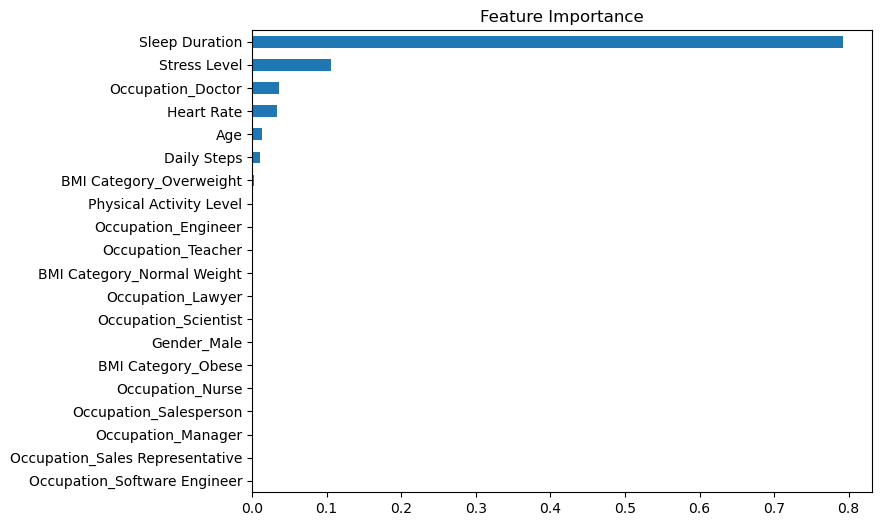

In [9]:
import matplotlib.pyplot as plt

importance.sort_values().plot(kind = 'barh', figsize = (8, 6))
plt.title("Feature Importance")
plt.show()

For now, I think the plan is that I will only alter the sleep duration and daily steps.
Heart rate and stress level are questionable when it comes to being able to alter easily.
Occupation_doctor is...an occupation, and the age is not controllable at all.

In [10]:
user_profile = X.mean().to_frame().T
print(user_profile)

         Age  Sleep Duration  Physical Activity Level  Stress Level  \
0  42.184492        7.132086                59.171123      5.385027   

   Heart Rate  Daily Steps  Gender_Male  Occupation_Doctor  \
0   70.165775   6816.84492     0.505348            0.18984   

   Occupation_Engineer  Occupation_Lawyer  Occupation_Manager  \
0             0.168449           0.125668            0.002674   

   Occupation_Nurse  Occupation_Sales Representative  Occupation_Salesperson  \
0          0.195187                         0.005348                0.085561   

   Occupation_Scientist  Occupation_Software Engineer  Occupation_Teacher  \
0              0.010695                      0.010695            0.106952   

   BMI Category_Normal Weight  BMI Category_Obese  BMI Category_Overweight  
0                     0.05615            0.026738                 0.395722  


In [11]:
import numpy as np

durations = np.linspace(5, 10, 50)

scores = []

for d in durations:
    row = user_profile.copy()
    row["Sleep Duration"] = d

    score = model.predict(row)[0]
    scores.append(score)

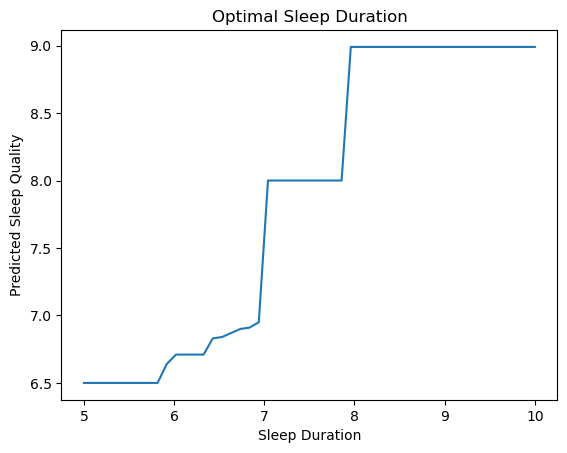

In [12]:
plt.plot(durations, scores)
plt.xlabel("Sleep Duration")
plt.ylabel("Predicted Sleep Quality")
plt.title("Optimal Sleep Duration")
plt.show()

Working on 2D Optimization here, this will be based on altering stress levels, however that works. Only reason I'm altering those is because it's the 2nd most altering variable.

In [13]:
durations = np.linspace(5, 10, 30)
stress_levels = np.linspace(1, 10, 30)

best_score = -float("inf")
best_combo = None

for d in durations:
    for s in stress_levels:
        row = user_profile.copy()
        row["Sleep Duration"] = d
        row["Stress Level"] = s

        score = model.predict(row)[0]
        if score > best_score:
            best_score = score
            best_combo = (d, s)

print("Best Sleep Duration:", best_combo[0])
print("Best Stress Level:", best_combo[1])
print("Predicted Sleep Quality:", best_score)

Best Sleep Duration: 8.10344827586207
Best Stress Level: 1.0
Predicted Sleep Quality: 9.0


In [14]:
scores_matrix = []

for d in durations:
    row_scores = []
    for s in stress_levels:
        
        row = user_profile.copy()
        row["Sleep Duration"] = d
        row["Stress Level"] = s
        
        score = model.predict(row)[0]
        row_scores.append(score)
    
    scores_matrix.append(row_scores)

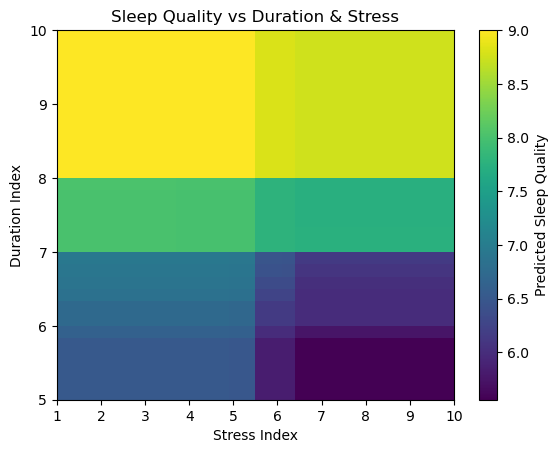

In [16]:
plt.imshow(scores_matrix, aspect='auto', origin='lower',
          extent = [
              1, 10,
              5, 10
          ]
)
plt.colorbar(label="Predicted Sleep Quality")
plt.xlabel("Stress Index")
plt.ylabel("Duration Index")
plt.title("Sleep Quality vs Duration & Stress")
plt.show()

Well, it's apparent that duration affects sleep quality more strongly relative to stress. This doesn't ignore stress' relevance, however, as it still affects sleep quality.

In [22]:
print("R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R2: 0.9840198562337968
MAE: 0.04439999999999999
